<a href="https://colab.research.google.com/github/Ayaawasis-collab/uas-anreg-wasis/blob/main/codimg_uas_proyek_wasis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

UAS ANREG

NAMA: MUHAMAD AKBAR WASISKO

NIM:2330109040008

#import library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson

#membaca data

In [ ]:
# membaca file CSV
data = pd.read_csv('/content/karhutla_306.csv')

# menampilkan 5 data pertama
data.head()

,waktu,jumlah_hotspot,curah_hujan,suhu,kelembaban,kecepatan_angin,luas_gambut,aktivitas_manusia
0,0,76.911601,125.374756,28.849312,71.975558,6.541920,2820.320182,1.408578
1,1,154.658274,153.322409,32.367300,66.624733,4.431157,2504.745987,-1.387185
2,2,-57.778927,176.799485,29.843943,69.826292,4.812832,6612.411938,1.083024
3,3,-163.705835,22.554959,29.471782,71.634328,1.360491,5110.644218,-0.447385
4,4,-218.210781,367.474176,31.878222,67.806022,4.168867,5972.949861,-0.675559


In [ ]:
print("Total Missing Value:", data.isna().sum().sum())
print("Total Duplikat:", data.duplicated().sum())

Total Missing Value: 0
Total Duplikat: 0


#deteksi outlier

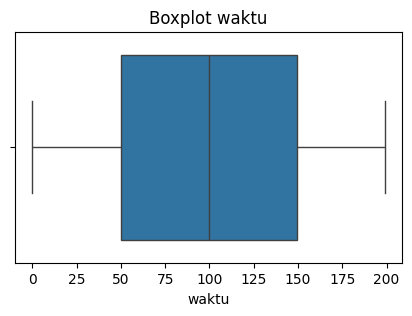

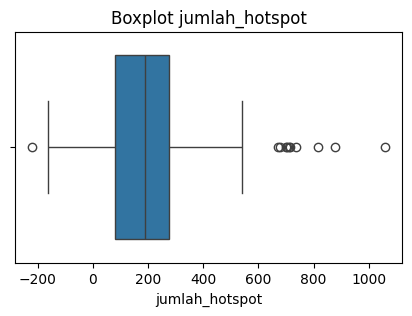

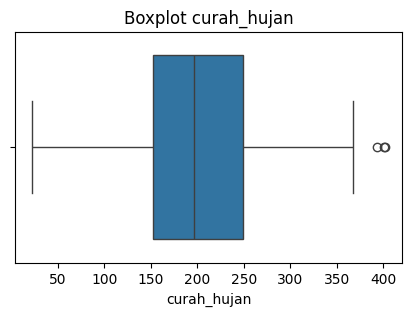

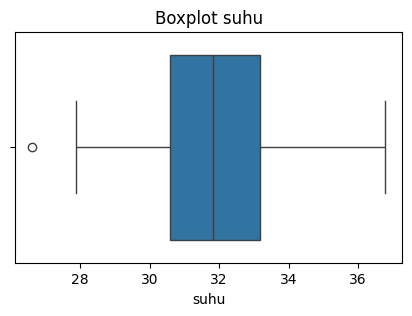

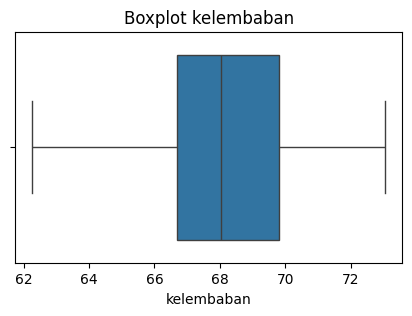

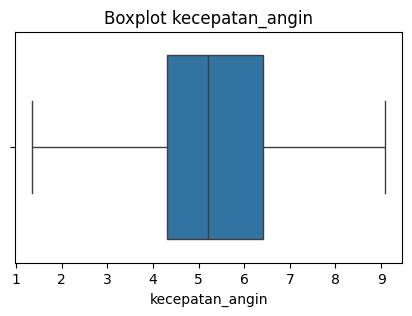

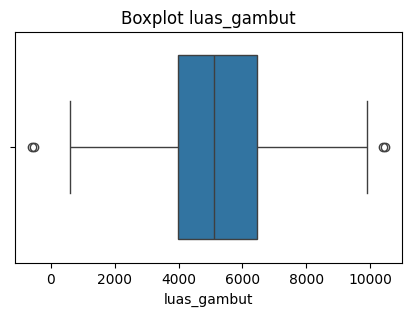

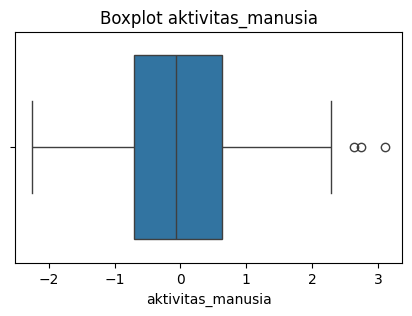

In [ ]:
for col in data.columns:
  plt.figure(figsize=(5,3))
  sns.boxplot(x=data[col])
  plt.title(f'Boxplot {col}')
  plt.show()

Berdasarkan hasil boxplot, variabel waktu tidak menunjukkan adanya outlier. Sementara itu, pada variabel lainnya ditemukan outlier yang ditandai dengan munculnya titik-titik kecil di luar whisker pada boxplot.


#scatter plot

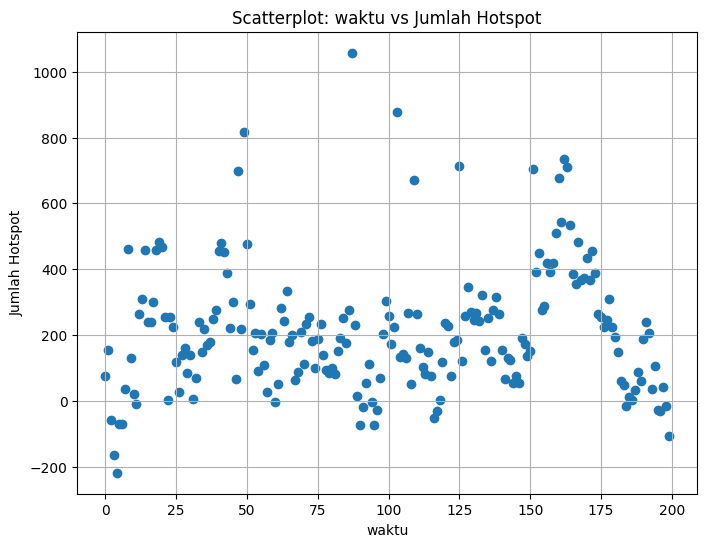

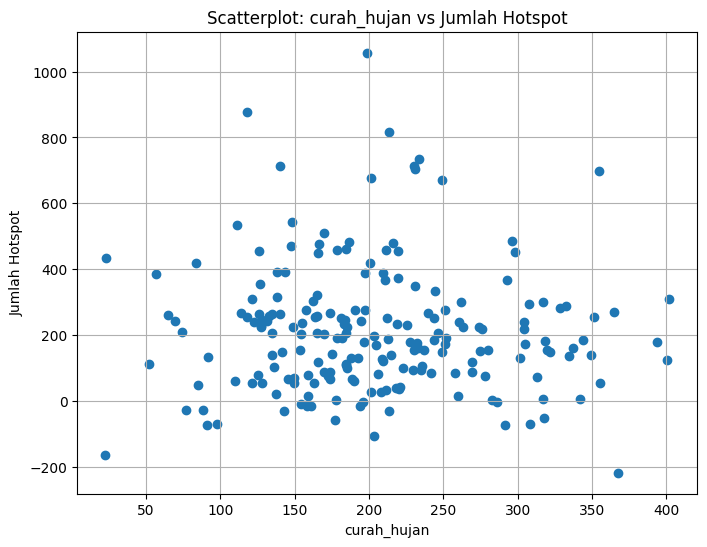

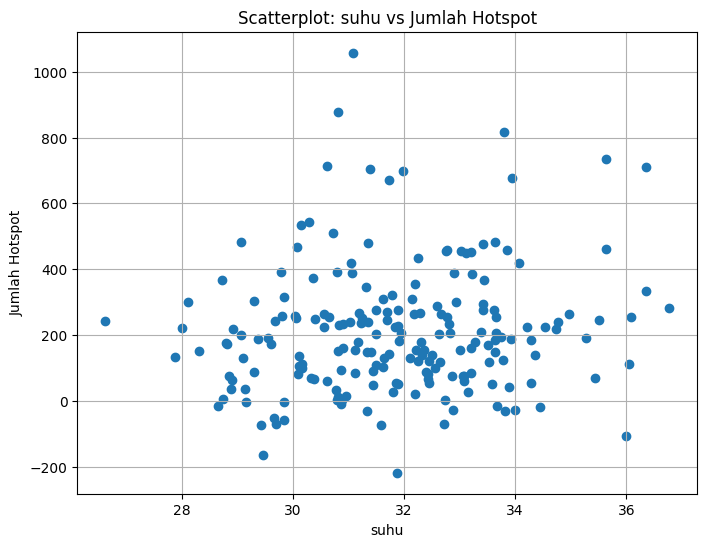

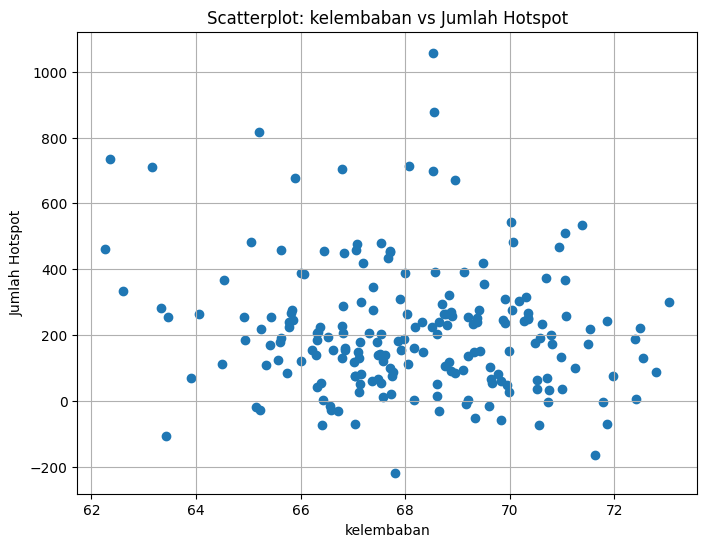

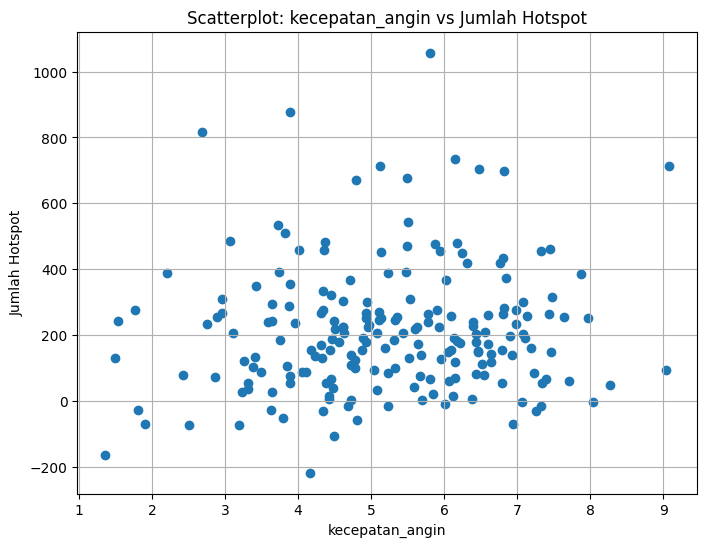

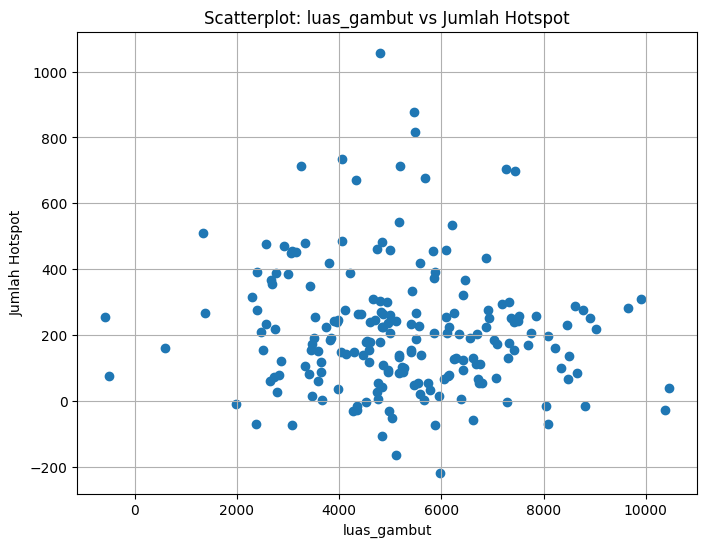

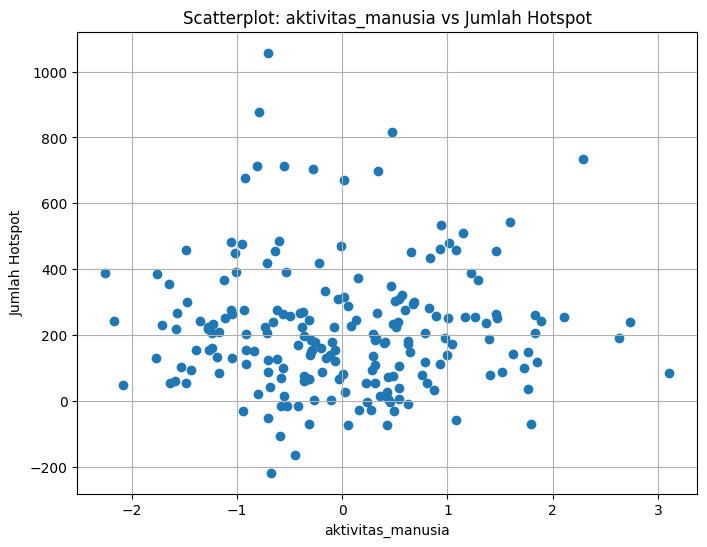

In [ ]:
y_plot_values = data['jumlah_hotspot']

for col_name in data.columns:
    if col_name == 'jumlah_hotspot':
        continue
    plt.figure(figsize=(8, 6))
    plt.scatter(data[col_name], y_plot_values)
    plt.xlabel(col_name)
    plt.ylabel('Jumlah Hotspot')
    plt.title(f'Scatterplot: {col_name} vs Jumlah Hotspot')
    plt.grid(True)
    plt.show()

#korelasi

In [ ]:
from scipy.stats import pearsonr

y_values = data['jumlah_hotspot']

for col_name in data.columns:
    if col_name == 'jumlah_hotspot':
        continue
    korelasi_pearson, p_value = pearsonr(data[col_name], y_values)
    print(f"\nkoefisien korelasi Pearson antara {col_name} dan Jumlah Hotspot: {korelasi_pearson:.3f} (p-value: {p_value:.3f})")


koefisien korelasi Pearson antara waktu dan Jumlah Hotspot: 0.083 (p-value: 0.241)

koefisien korelasi Pearson antara curah_hujan dan Jumlah Hotspot: -0.038 (p-value: 0.594)

koefisien korelasi Pearson antara suhu dan Jumlah Hotspot: 0.122 (p-value: 0.086)

koefisien korelasi Pearson antara kelembaban dan Jumlah Hotspot: -0.144 (p-value: 0.042)

koefisien korelasi Pearson antara kecepatan_angin dan Jumlah Hotspot: 0.095 (p-value: 0.183)

koefisien korelasi Pearson antara luas_gambut dan Jumlah Hotspot: -0.092 (p-value: 0.194)

koefisien korelasi Pearson antara aktivitas_manusia dan Jumlah Hotspot: -0.006 (p-value: 0.933)


#pembersihan outlier

In [ ]:
data_clean = data.copy()

for col in data_clean.select_dtypes(include='number').columns:
    Q1 = data_clean[col].quantile(0.25)
    Q3 = data_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data_clean = data_clean[
        (data_clean[col] >= lower) &
        (data_clean[col] <= upper)
    ]

#deteksi outlier

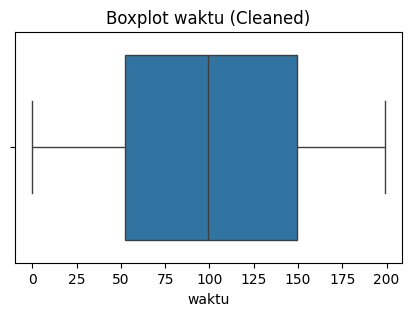

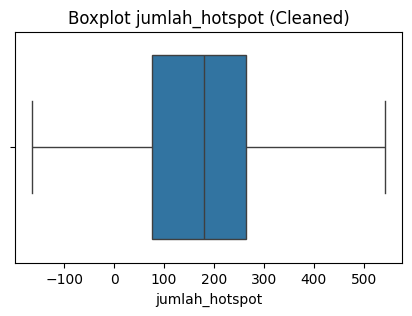

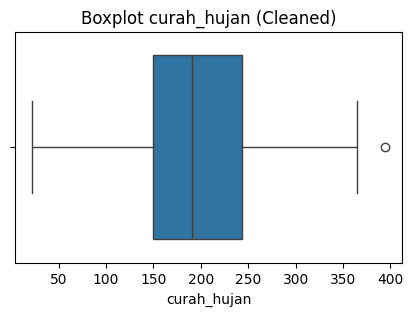

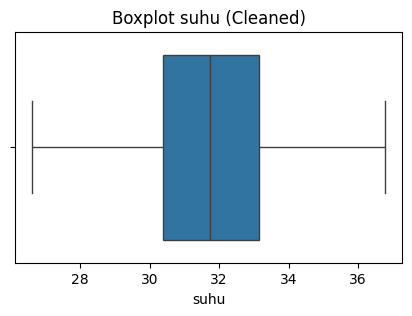

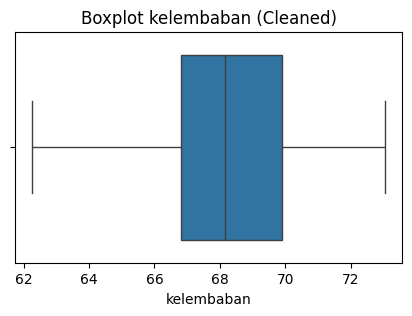

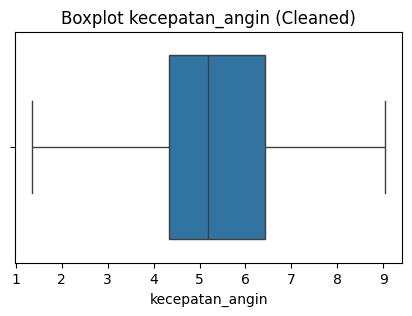

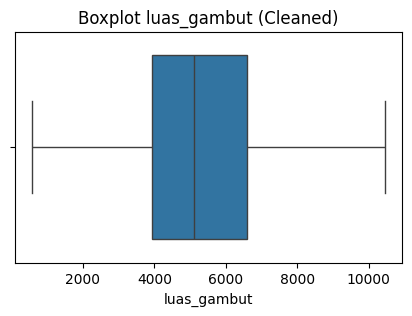

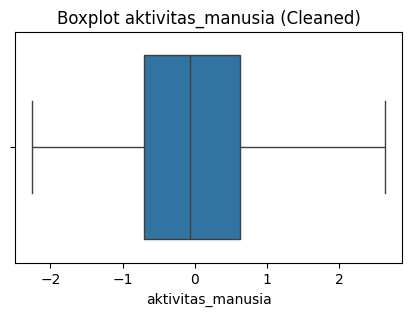

In [ ]:
for col in data_clean.columns:
  plt.figure(figsize=(5,3))
  sns.boxplot(x=data_clean[col])
  plt.title(f'Boxplot {col} (Cleaned)')
  plt.show()

#scatter plot

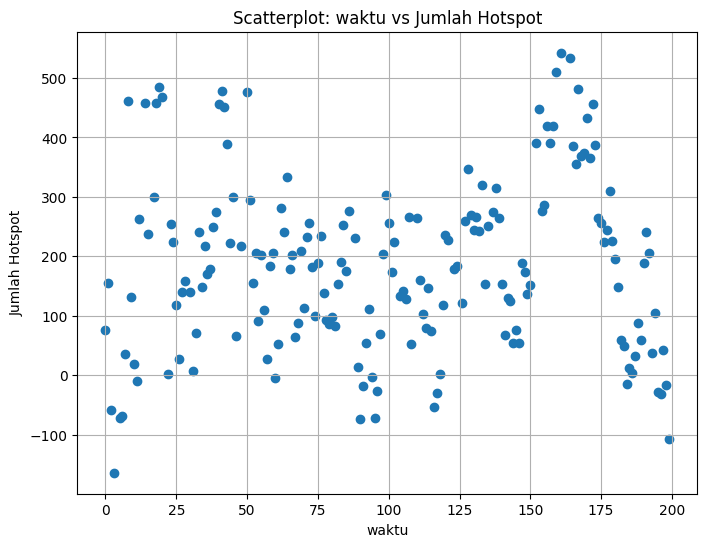

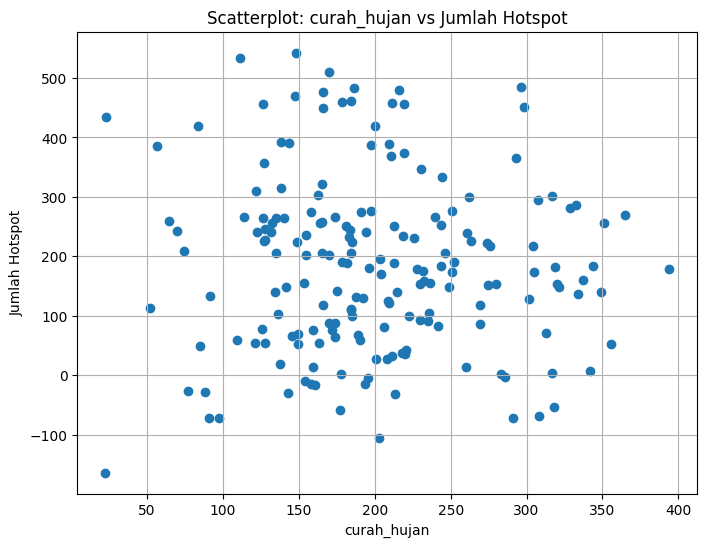

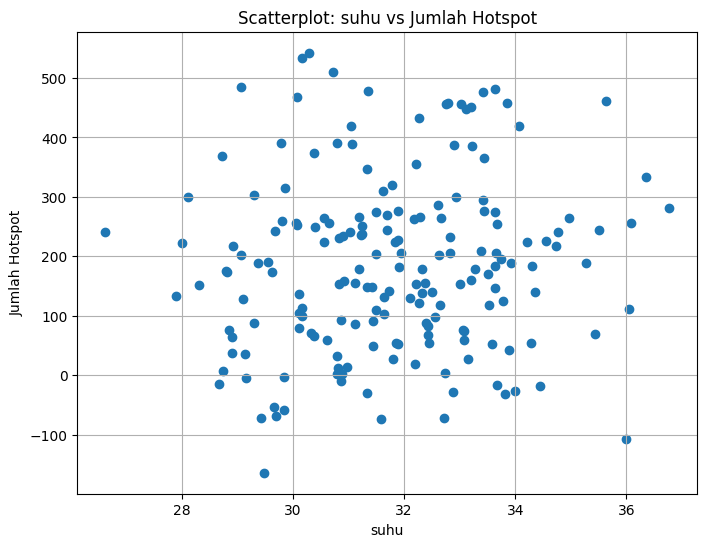

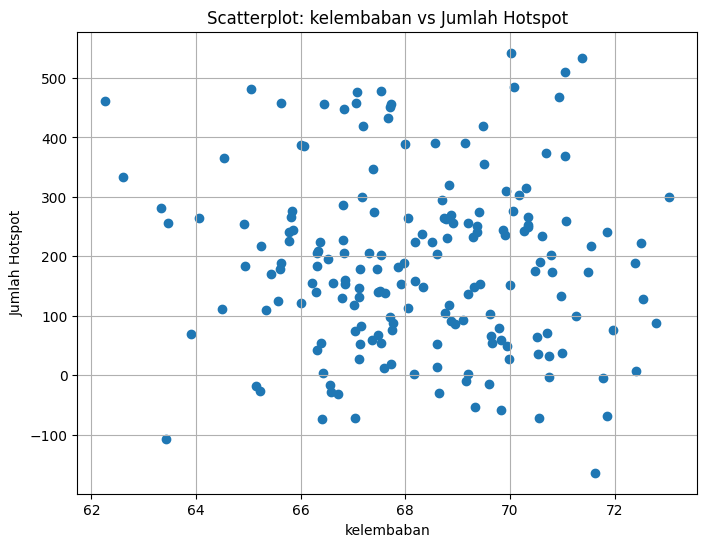

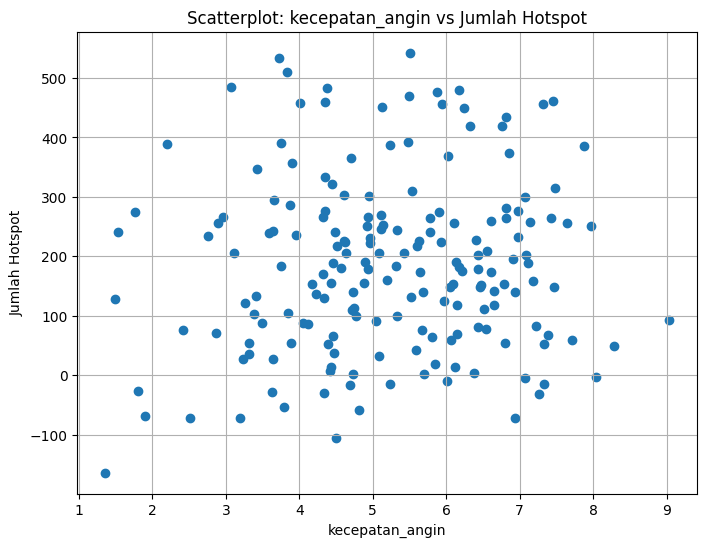

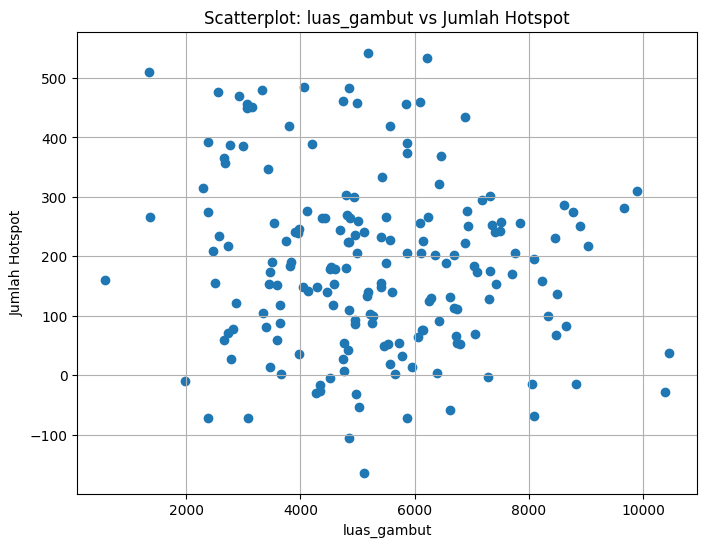

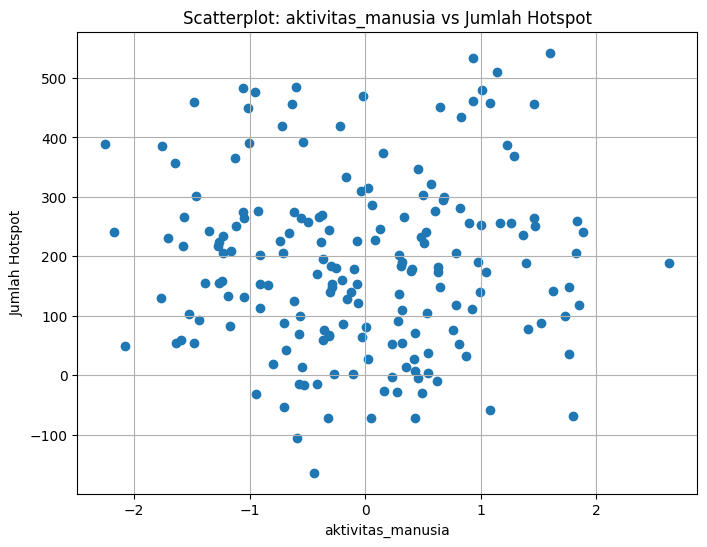

In [ ]:
y_plot_values_clean = data_clean['jumlah_hotspot']

for col_name in data_clean.columns:
    if col_name == 'jumlah_hotspot':
        continue
    plt.figure(figsize=(8, 6))
    plt.scatter(data_clean[col_name], y_plot_values_clean)
    plt.xlabel(col_name)
    plt.ylabel('Jumlah Hotspot')
    plt.title(f'Scatterplot: {col_name} vs Jumlah Hotspot')
    plt.grid(True)
    plt.show()

#korelasi

In [ ]:
from scipy.stats import pearsonr

y_values_clean = data_clean['jumlah_hotspot']

for col_name in data_clean.columns:
    if col_name == 'jumlah_hotspot':
        continue
    korelasi_pearson, p_value = pearsonr(data_clean[col_name], y_values_clean)
    print(f"\nkoefisien korelasi Pearson antara {col_name} dan Jumlah Hotspot: {korelasi_pearson:.3f} (p-value: {p_value:.3f})")


koefisien korelasi Pearson antara waktu dan Jumlah Hotspot: 0.059 (p-value: 0.431)

koefisien korelasi Pearson antara curah_hujan dan Jumlah Hotspot: -0.046 (p-value: 0.535)

koefisien korelasi Pearson antara suhu dan Jumlah Hotspot: 0.092 (p-value: 0.213)

koefisien korelasi Pearson antara kelembaban dan Jumlah Hotspot: -0.075 (p-value: 0.314)

koefisien korelasi Pearson antara kecepatan_angin dan Jumlah Hotspot: 0.081 (p-value: 0.273)

koefisien korelasi Pearson antara luas_gambut dan Jumlah Hotspot: -0.135 (p-value: 0.068)

koefisien korelasi Pearson antara aktivitas_manusia dan Jumlah Hotspot: 0.008 (p-value: 0.920)


#model 1

In [ ]:
X = data_clean.drop(columns='jumlah_hotspot')
Y = data_clean[['jumlah_hotspot']]

Y.head()

,jumlah_hotspot
0,76.911601
1,154.658274
2,-57.778927
3,-163.705835
5,-71.637399


In [ ]:
X.head()

,waktu,curah_hujan,suhu,kelembaban,kecepatan_angin,luas_gambut,aktivitas_manusia
0,0,125.374756,28.849312,71.975558,6.541920,2820.320182,1.408578
1,1,153.322409,32.367300,66.624733,4.431157,2504.745987,-1.387185
2,2,176.799485,29.843943,69.826292,4.812832,6612.411938,1.083024
3,3,22.554959,29.471782,71.634328,1.360491,5110.644218,-0.447385
5,5,97.571995,32.720129,67.047971,6.939958,2379.665515,-0.318034


In [ ]:
Y.head()

,jumlah_hotspot
0,76.911601
1,154.658274
2,-57.778927
3,-163.705835
5,-71.637399


##split data(bagi data menjadi training dan test)

In [ ]:
from sklearn.model_selection import train_test_split

X_admit_train, X_admit_test, Y_admit_train, Y_admit_test = train_test_split(X, Y, test_size=0.20, random_state=16)

##model training

In [ ]:
from sklearn.linear_model import LinearRegression

X_train = X_admit_train
X_test  = X_admit_test
Y_train = Y_admit_train.values.ravel()
Y_test  = Y_admit_test.values.ravel()

model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

##uji asumsi klasik

##uji normalitas residual

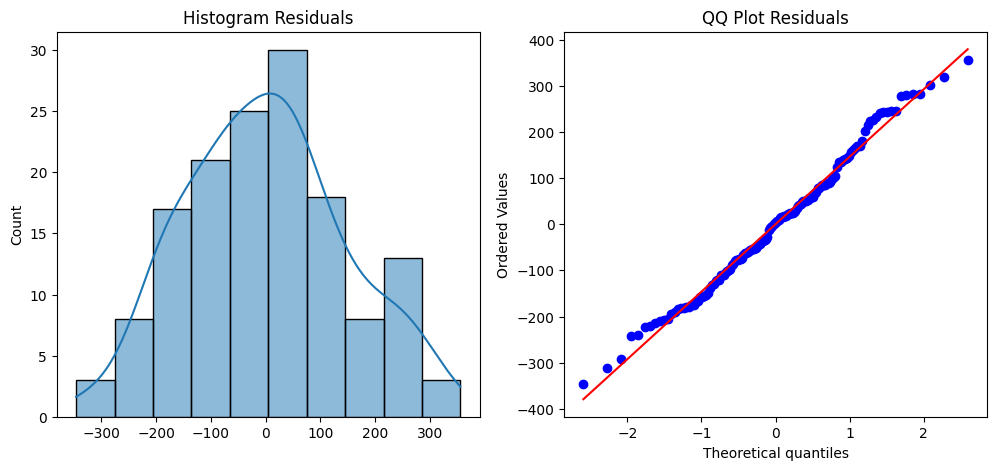

In [ ]:

import scipy.stats as stats
import matplotlib.pyplot as plt

Y_pred_train = model.predict(X_train)

residuals = Y_train - Y_pred_train

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(residuals, kde=True)
plt.title("Histogram Residuals")

plt.subplot(1,2,2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot Residuals")

plt.show()

Berdasarkan histogram dan plot yang diperoleh, residual model tampak menyebar mengikuti distribusi normal, sehingga asumsi normalitas dapat dikatakan telah terpenuhi.


##uji heterokedastisitas

In [ ]:
from statsmodels.stats.api import het_breuschpagan
from statsmodels.tools.tools import add_constant

X_train_const = add_constant(X_train)
bp_test = het_breuschpagan(residuals, X_train_const)

labels = [
    'LM Statistic',
    'LM-Test p-value',
    'F-Statistic',
    'F-Test p-value'
]

results = dict(zip(labels, bp_test))

for key, value in results.items():
    print(f"{key}: {value}")

LM Statistic: 10.87320581359192
LM-Test p-value: 0.14424614453871729
F-Statistic: 1.5863433105922442
F-Test p-value: 0.1443256413535044


Berdasarkan uji Breusch-Pagan, diperoleh p-value sebesar 0.144 (>0.05) sehingga dapat disimpulkan tidak mengalami heterokedastisitas, dan asumsi terpenuhi

##uji multikolinearitas

In [ ]:
X_train = X_train.copy()
X_test  = X_test.copy()

from statsmodels.tools.tools import add_constant
X_vif = add_constant(X_train)

from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

vif_df = pd.DataFrame()
vif_df["X"] = X_vif.columns
vif_df["vif_score"] = [vif(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_df = vif_df[vif_df.X != "const"]

print(vif_df)

                   X  vif_score
1              waktu   1.047667
2        curah_hujan   1.056368
3               suhu   5.440109
4         kelembaban   5.575293
5    kecepatan_angin   1.042473
6        luas_gambut   1.011013
7  aktivitas_manusia   1.106853


Terjadi multikolinearitas pada model yang ditunjukkan oleh adanya dua variabel dengan nilai VIF > 5, yaitu variabel suhu dan kelembaban. Oleh karena itu, kedua variabel tersebut dikeluarkan dari model.


In [ ]:
X_train_new = X_train.drop(columns=['kelembaban','suhu'])
X_test_new  = X_test.drop(columns=['kelembaban','suhu'])

from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

X_vif = add_constant(X_train_new)

vif_df = pd.DataFrame()
vif_df["X"] = X_vif.columns
vif_df["vif_score"] = [
    vif(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_df = vif_df[vif_df.X != "const"]

print(vif_df)

                   X  vif_score
1              waktu   1.046474
2        curah_hujan   1.055925
3    kecepatan_angin   1.020076
4        luas_gambut   1.007162
5  aktivitas_manusia   1.026181


##uji autokorelasi

In [ ]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(residuals)
print(f"Durbin-Watson = {dw:.3f}")

Durbin-Watson = 2.052


Hasil Durbin-Watson 2.052 (melebihi 2), ada autokorelasi sehingga harus diatasi terlebih dahulu

## atasi autokorelasi dengan metode GLSAR

In [ ]:
# variabel independen
X = data[['waktu',
          'curah_hujan',
          'kecepatan_angin',
          'luas_gambut',
          'aktivitas_manusia']]

# variabel dependen
y = data['jumlah_hotspot']

# menambahkan konstanta
X = sm.add_constant(X)

# model OLS awal
model_ols = sm.OLS(y, X).fit()

# cek Durbin Watson awal
dw_awal = durbin_watson(model_ols.resid)

print("Durbin Watson Awal :", dw_awal)

# GLSAR untuk mengatasi autokorelasi

model_glsar = sm.GLSAR(y, X, rho=1)

hasil_glsar = model_glsar.iterative_fit(maxiter=10)

# ringkasan hasil model
print(hasil_glsar.summary())

# cek Durbin Watson setelah perbaikan
dw_akhir = durbin_watson(hasil_glsar.resid)

print("\nDurbin Watson Setelah GLSAR :", dw_akhir)

Durbin Watson Awal : 0.9549477114892814
                           GLSAR Regression Results                           
Dep. Variable:         jumlah_hotspot   R-squared:                       0.041
Model:                          GLSAR   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     1.667
Date:                Wed, 27 May 2026   Prob (F-statistic):              0.144
Time:                        13:58:37   Log-Likelihood:                -1295.3
No. Observations:                 199   AIC:                             2603.
Df Residuals:                     193   BIC:                             2622.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

Hasil Durbin-Watson 0.9277 , tidak ada autokorelasi sehingga asumsi terpenuhi

Buat model baru dengan X_train_new

In [ ]:
from sklearn.linear_model import LinearRegression

model_new = LinearRegression()
model_new.fit(X_train_new, Y_train)

LinearRegression()

In [ ]:
coef_df = pd.DataFrame({
    'feature':['intercept'] + X_train_new.columns.tolist(),
    'coefficient':[model_new.intercept_] + list(model_new.coef_)
})

coef_df

,feature,coefficient
0,intercept,223.208553
1,waktu,-0.018991
2,curah_hujan,-0.089358
3,kecepatan_angin,7.773087
4,luas_gambut,-0.011191
5,aktivitas_manusia,-1.265002


Model: Y = 223.208553 -0.018991*Waktu -0.089358*Curah Hujan + 7.773087*Kecepatan Angin -0.011191*Luas Gambut -1.265002*Aktivitas Manusia

##menggunakan model ols

In [ ]:
import statsmodels.api as sm

X_train_const = sm.add_constant(X_train)
model_ols = sm.OLS(Y_train, X_train_const).fit()
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                 -0.015
Method:                 Least Squares   F-statistic:                    0.7038
Date:                Wed, 27 May 2026   Prob (F-statistic):              0.669
Time:                        14:05:47   Log-Likelihood:                -933.39
No. Observations:                 146   AIC:                             1883.
Df Residuals:                     138   BIC:                             1907.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              -582.9116   1373.87

##evaluasi model

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

Y_train_pred = model_new.predict(X_train_new)

r2_train = r2_score(Y_train, Y_train_pred)
mae_train = mean_absolute_error(Y_train, Y_train_pred)
rmse_train = np.sqrt(mean_squared_error(Y_train, Y_train_pred))

print("Train R2:", r2_train)
print("Train MAE:", mae_train)
print("Train RMSE:", rmse_train)

Train R2: 0.03188998370333995
Train MAE: 117.7382840425087
Train RMSE: 144.8149675720613


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

Y_test_pred = model_new.predict(X_test_new)

r2_test = r2_score(Y_test, Y_test_pred)
mae_test = mean_absolute_error(Y_test, Y_test_pred)
rmse_test = np.sqrt(mean_squared_error(Y_test, Y_test_pred))

print("Test R2:", r2_test)
print("Test MAE:", mae_test)
print("Test RMSE:", rmse_test)

Test R2: -0.01073826502769304
Test MAE: 112.59723042254541
Test RMSE: 141.18737875907988


Hasil evaluasi model menunjukkan bahwa model regresi memiliki kemampuan prediksi yang masih rendah dengan nilai R2 train sebesar 0.031 dan R2 test sebesar -0.0107. Nilai tersebut menunjukkan variabel independent belum mampu menjelaskan variasi jumlah hotspot secara optimal. Selain itu, predik model masih memiliki error yang besar (MAE dan RMSE)

#model 2

In [ ]:
X1 = data_clean[['curah_hujan','luas_gambut']]
Y1 = data_clean[['jumlah_hotspot']]

In [ ]:
X1.head()

,curah_hujan,luas_gambut
0,125.374756,2820.320182
1,153.322409,2504.745987
2,176.799485,6612.411938
3,22.554959,5110.644218
5,97.571995,2379.665515


In [ ]:

Y1.head()

,jumlah_hotspot
0,76.911601
1,154.658274
2,-57.778927
3,-163.705835
5,-71.637399


##splitting data

In [ ]:
from sklearn.model_selection import train_test_split

X1_admit_train, X1_admit_test, Y1_admit_train, Y1_admit_test = train_test_split(X1, Y1, test_size=0.20, random_state=16)

##model training

In [ ]:
from sklearn.linear_model import LinearRegression

X1_train = X1_admit_train
X1_test  = X1_admit_test
Y1_train = Y1_admit_train.values.ravel()
Y1_test  = Y1_admit_test.values.ravel()

##gunakan ols

In [ ]:
import statsmodels.api as sm

X1_train_const = sm.add_constant(X1_train)
model_ols = sm.OLS(Y1_train, X1_train_const).fit()
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     1.883
Date:                Wed, 27 May 2026   Prob (F-statistic):              0.156
Time:                        14:12:06   Log-Likelihood:                -934.05
No. Observations:                 146   AIC:                             1874.
Df Residuals:                     143   BIC:                             1883.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         263.5010     47.256      5.576      

##evaluasi model

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

Y1_train_pred = model_ols.predict(X1_train_const)

r2_train = r2_score(Y1_train, Y1_train_pred)
mae_train = mean_absolute_error(Y1_train, Y1_train_pred)
rmse_train = np.sqrt(mean_squared_error(Y1_train, Y1_train_pred))

print("Train R2:", r2_train)
print("Train MAE:", mae_train)
print("Train RMSE:", rmse_train)

Train R2: 0.025657078913766562
Train MAE: 117.63545561363333
Train RMSE: 145.28039491750346


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm

X1_test_const = sm.add_constant(X1_test)
Y1_test_pred = model_ols.predict(X1_test_const)

r2_test = r2_score(Y1_test, Y1_test_pred)
mae_test = mean_absolute_error(Y1_test, Y1_test_pred)
rmse_test = np.sqrt(mean_squared_error(Y1_test, Y1_test_pred))

print("Test R2:", r2_test)
print("Test MAE:", mae_test)
print("Test RMSE:", rmse_test)

Test R2: -0.01368822325510588
Test MAE: 112.67993969660391
Test RMSE: 141.3932646090106


#model 3

In [ ]:
X2 = data_clean[['suhu','kelembaban']]
Y2 = data_clean[['jumlah_hotspot']]

##splitting data

In [ ]:
from sklearn.model_selection import train_test_split

X2_admit_train, X2_admit_test, Y2_admit_train, Y2_admit_test = train_test_split(X2, Y2, test_size=0.20, random_state=16)

In [ ]:
X2.head()

,suhu,kelembaban
0,28.849312,71.975558
1,32.367300,66.624733
2,29.843943,69.826292
3,29.471782,71.634328
5,32.720129,67.047971


In [ ]:
Y2.head()

,jumlah_hotspot
0,76.911601
1,154.658274
2,-57.778927
3,-163.705835
5,-71.637399


##model training

In [ ]:
from sklearn.linear_model import LinearRegression

X2_train = X2_admit_train
X2_test  = X2_admit_test
Y2_train = Y2_admit_train.values.ravel()
Y2_test  = Y2_admit_test.values.ravel()

##gunakan ols

In [ ]:
import statsmodels.api as sm

X2_train_const = sm.add_constant(X2_train)
model_ols = sm.OLS(Y2_train, X2_train_const).fit()
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.011
Method:                 Least Squares   F-statistic:                    0.2463
Date:                Wed, 27 May 2026   Prob (F-statistic):              0.782
Time:                        14:16:40   Log-Likelihood:                -935.70
No. Observations:                 146   AIC:                             1877.
Df Residuals:                     143   BIC:                             1886.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -689.1368   1327.541     -0.519      0.6

##evaluasi model

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

Y2_train_pred = model_ols.predict(X2_train_const)

r2_train = r2_score(Y2_train, Y2_train_pred)
mae_train = mean_absolute_error(Y2_train, Y2_train_pred)
rmse_train = np.sqrt(mean_squared_error(Y2_train, Y2_train_pred))

print("Train R2:", r2_train)
print("Train MAE:", mae_train)
print("Train RMSE:", rmse_train)

Train R2: 0.003433070132371152
Train MAE: 117.62482411290657
Train RMSE: 146.92791994059598


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm

X2_test_const = sm.add_constant(X2_test)
Y2_test_pred = model_ols.predict(X2_test_const)

r2_test = r2_score(Y2_test, Y2_test_pred)
mae_test = mean_absolute_error(Y2_test, Y2_test_pred)
rmse_test = np.sqrt(mean_squared_error(Y2_test, Y2_test_pred))

print("Test R2:", r2_test)
print("Test MAE:", mae_test)
print("Test RMSE:", rmse_test)

Test R2: -0.004629974686310767
Test MAE: 109.03444277552198
Test RMSE: 140.7601067044193
